In [53]:
# Predict Hourly Rate using Linear Regression Model:
# 1. Education (Years)
# 2. Professional Training (Yes=1, No=0)

# =========================
# STEP 1: Import Libraries
# =========================
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score


In [54]:
# =========================
# STEP 2: Create Dataset
# =========================
data = pd.read_csv('Salary_payment.csv')

df = pd.DataFrame(data)

print("Full Dataset:")
print(df)

Full Dataset:
     Education  Training  HourlyRate
0           16         1          95
1           15         0          68
2           12         1          74
3           18         1         128
4           16         0         103
..         ...       ...         ...
96          18         1         130
97          19         0         111
98          20         1         137
99          21         0         123
100         22         1         149

[101 rows x 3 columns]


In [55]:
# =========================
# STEP 3: Define Features and Target
# =========================

# X = input variables
X = df[["Education", "Training"]]

# y = output variable
y = df["HourlyRate"]

In [56]:
# =========================
# STEP 4: Split into Train and Test Data
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,      # 25% test data
    random_state=42
)

In [57]:
# =========================
# SEE TRAIN AND TEST DATA
# =========================

print("\nX_train:")
print(X_train)

print("\nX_test:")
print(X_test)

print("\ny_train:")
print(y_train)

print("\ny_test:")
print(y_test)


X_train:
    Education  Training
40         10         0
72         20         1
9          14         1
96         18         1
11         13         0
..        ...       ...
60         19         1
71         19         0
14         10         0
92         14         1
51         20         1

[75 rows x 2 columns]

X_test:
    Education  Training
84         19         1
55         10         1
66         14         1
67         15         1
45         15         1
39         11         0
22         13         1
44         16         1
10         17         1
0          16         1
18         12         0
30         17         1
97         19         0
33         13         0
77         12         0
4          16         0
93         15         0
78         13         1
12         19         1
31         15         0
76         11         0
89         11         1
26         11         1
42         21         1
70         18         1
15         22         1

y_train:
40     50
72

In [58]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(75, 2)
(26, 2)
(75,)
(26,)


In [59]:
# =========================
# STEP 5: Train Linear Regression Model
# =========================

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [60]:
# =========================
# STEP 6: Make Predictions
# =========================

y_pred = model.predict(X_test)

print("\nPredictions:")
print(y_pred)


Predictions:
[127.14893617  61.08510638  90.44680851  97.78723404  97.78723404
  52.94042553  83.10638298 105.12765957 112.46808511 105.12765957
  60.28085106 112.46808511 111.66382979  67.6212766   60.28085106
  89.64255319  82.30212766  83.10638298 127.14893617  82.30212766
  52.94042553  68.42553191  68.42553191 141.82978723 119.80851064
 149.17021277]


In [61]:
print("Actual Values:")
print(y_test.to_numpy())

Actual Values:
[133  63  84  96  93  55  80 104 110  95  61 109 111  65  62 103  71  81
 125  70  57  68  69 140 126 145]


In [62]:
# =========================
# STEP 7: Evaluate Model
# =========================

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nMean Absolute Error:", mae)
print("R2 Score:", r2)


Mean Absolute Error: 4.128314238952539
R2 Score: 0.9574458948309653


In [63]:
# =========================
# STEP 8: Model Equation
# =========================

print("\nIntercept:", model.intercept_)
print("Coefficients:", model.coef_)

# Equation:
# HourlyRate =
# intercept +
# coef1 * Education +
# coef2 * Training



Intercept: -27.804255319148908
Coefficients: [ 7.34042553 15.48510638]


In [64]:
# =========================
# STEP 9: Predict NEW DATA
# =========================

# Example:
# Education = 17 years
# Training = Yes (1)

new_data = pd.DataFrame({
    "Education": [18],
    "Training": [1]
})

prediction = model.predict(new_data)

print("\nPrediction for New Data:")
print("Predicted Hourly Rate =", prediction[0])


Prediction for New Data:
Predicted Hourly Rate = 119.80851063829788


## Resources

Let's visualize the relationship between `Education` and `HourlyRate`.

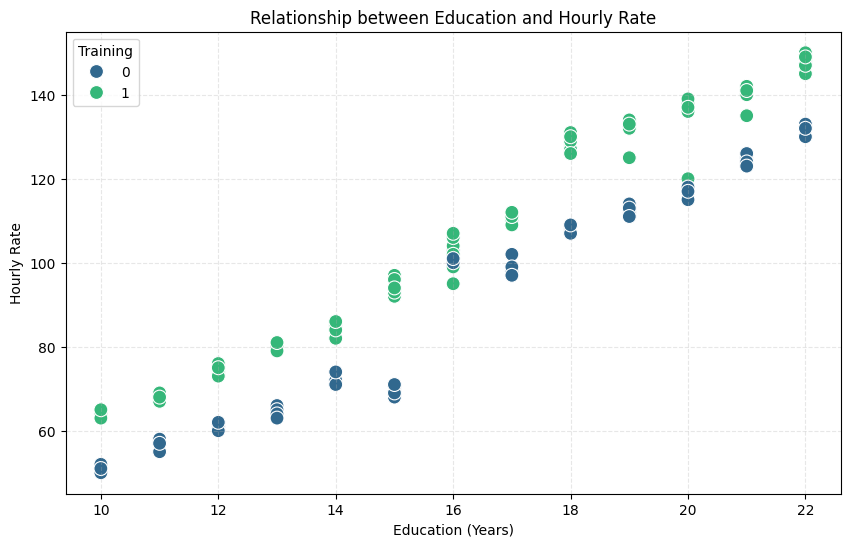

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x='Education', y='HourlyRate', data=df, hue='Training', palette='viridis', s=100)
plt.title('Relationship between Education and Hourly Rate')
plt.xlabel('Education (Years)')
plt.ylabel('Hourly Rate')
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()